# Notebook 04: Machine Learning Model Comparison
## Research Question 2: Which machine learning model best classifies sentiment in Amazon product reviews?

This notebook trains and evaluates four sentiment classification models on the cleaned and scored corpus produced in Notebook 03. All models are evaluated on an identical held-out test set to ensure a fair and consistent comparison.

**Models compared:** Logistic Regression · Random Forest · XGBoost · LSTM  
**Input:** reviews_scored.csv (93,052 reviews)  
**Output:** reviews_ml_scored.csv · lr_sentiment_model.pkl · tfidf_vectoriser.pkl

## Stage 1: Data Preparation

In [1]:
# Step 1: Environment setup and loading of the scored corpus
# Google Drive is mounted and the scored corpus produced in the sentiment
# analysis stage is loaded. The binary classification target is derived
# by mapping star ratings to sentiment labels and dropping neutral
# three-star reviews, which are too ambiguous for binary classification.

from google.colab import drive
import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

drive.mount('/content/drive')

# Directory paths are established
output_dir = '/content/drive/MyDrive/MSc-Project/outputs'
os.makedirs(output_dir, exist_ok=True)

# The scored corpus produced in notebook 03 is loaded
df = pd.read_csv('/content/drive/MyDrive/MSc-Project/data/reviews_scored.csv')
print("Corpus loaded:", df.shape)
print(df.columns.tolist())

# A binary sentiment label is derived from the star rating
# Ratings 4-5 are positive, ratings 1-2 are negative, rating 3 is dropped
df_binary = df[df['rating'] != 3].copy()
df_binary['sentiment'] = df_binary['rating'].apply(
    lambda r: 1 if r >= 4 else 0
)

print()
print("After dropping three-star reviews:", f"{len(df_binary):,} reviews")
print()
print(df_binary['sentiment'].value_counts())
print()
print("Class balance:")
print(df_binary['sentiment'].value_counts(normalize=True).round(4))

Mounted at /content/drive
Corpus loaded: (93052, 21)
['rating', 'title', 'text', 'images', 'asin', 'parent_asin', 'user_id', 'timestamp', 'helpful_vote', 'verified_purchase', 'review_date', 'clean_text', 'clean_title', 'clean_word_count', 'vader_compound', 'vader_label', 'rating_label', 'roberta_label', 'roberta_prob_negative', 'roberta_prob_neutral', 'roberta_prob_positive']

After dropping three-star reviews: 86,595 reviews

sentiment
1    72091
0    14504
Name: count, dtype: int64

Class balance:
sentiment
1    0.8325
0    0.1675
Name: proportion, dtype: float64


## Stage 2: Feature Extraction and Train-Test Split

In [2]:
# Step 2: TF-IDF feature extraction and train-test split
# The cleaned review text is converted to numerical TF-IDF features.
# A maximum of 50,000 features is retained to balance representational
# richness against computational cost. The data is split into training
# and test sets using a fixed random seed for reproducibility.

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split

# Any missing text is replaced with an empty string
df_binary['clean_text'] = df_binary['clean_text'].fillna('')

# TF-IDF features are extracted from the cleaned review text
tfidf = TfidfVectorizer(
    max_features=50000,
    ngram_range=(1, 2),
    min_df=2,
    sublinear_tf=True
)

X = tfidf.fit_transform(df_binary['clean_text'])
y = df_binary['sentiment'].values

print("TF-IDF matrix shape:", X.shape)
print("Target variable shape:", y.shape)

# The data is split into training and test sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

print()
print("Training set:", X_train.shape)
print("Test set:", X_test.shape)
print()
print("Training class balance:")
unique, counts = np.unique(y_train, return_counts=True)
for u, c in zip(unique, counts):
    print(f"  Class {u}: {c:,} ({c/len(y_train)*100:.1f}%)")

TF-IDF matrix shape: (86595, 50000)
Target variable shape: (86595,)

Training set: (69276, 50000)
Test set: (17319, 50000)

Training class balance:
  Class 0: 11,603 (16.7%)
  Class 1: 57,673 (83.3%)


## Stage 3: Baseline Model — Logistic Regression

In [3]:
# Step 3: Logistic Regression baseline model
# Logistic Regression is trained as the baseline classifier against which
# the more complex models are benchmarked. Class weights are applied to
# address the class imbalance identified in the training set.

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (classification_report, confusion_matrix,
                             accuracy_score, f1_score)
import time

# The model is defined with balanced class weights and a fixed random seed
lr_model = LogisticRegression(
    class_weight='balanced',
    max_iter=1000,
    random_state=42,
    solver='lbfgs',
    C=1.0
)

# Training time is recorded for comparison across models
start = time.time()
lr_model.fit(X_train, y_train)
lr_time = time.time() - start

# Predictions are generated on the held-out test set
y_pred_lr = lr_model.predict(X_test)

# Performance metrics are computed
lr_accuracy = accuracy_score(y_test, y_pred_lr)
lr_f1 = f1_score(y_test, y_pred_lr, average='weighted')
lr_cm = confusion_matrix(y_test, y_pred_lr)

print("=" * 50)
print("Logistic Regression — Baseline Model")
print("=" * 50)
print(f"Training time      : {lr_time:.1f} seconds")
print(f"Overall accuracy   : {lr_accuracy*100:.2f}%")
print(f"Weighted F1 score  : {lr_f1:.4f}")
print()
print("Classification report:")
print(classification_report(y_test, y_pred_lr,
      target_names=['Negative', 'Positive']))
print()
print("Confusion matrix:")
print(lr_cm)

Logistic Regression — Baseline Model
Training time      : 2.6 seconds
Overall accuracy   : 93.52%
Weighted F1 score  : 0.9379

Classification report:
              precision    recall  f1-score   support

    Negative       0.75      0.93      0.83      2901
    Positive       0.98      0.94      0.96     14418

    accuracy                           0.94     17319
   macro avg       0.87      0.93      0.89     17319
weighted avg       0.94      0.94      0.94     17319


Confusion matrix:
[[ 2684   217]
 [  905 13513]]


## Stage 4: Random Forest

In [4]:
# Step 4: Random Forest classifier
# A Random Forest ensemble is trained on the TF-IDF feature matrix.
# One hundred estimators are used to balance predictive performance
# against computational cost. Class weights are applied to address
# the class imbalance identified in the training set.

from sklearn.ensemble import RandomForestClassifier

# The model is defined with balanced class weights
rf_model = RandomForestClassifier(
    n_estimators=100,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)

# Training time is recorded
start = time.time()
rf_model.fit(X_train, y_train)
rf_time = time.time() - start

# Predictions are generated on the held-out test set
y_pred_rf = rf_model.predict(X_test)

# Performance metrics are computed
rf_accuracy = accuracy_score(y_test, y_pred_rf)
rf_f1 = f1_score(y_test, y_pred_rf, average='weighted')
rf_cm = confusion_matrix(y_test, y_pred_rf)

print("=" * 50)
print("Random Forest")
print("=" * 50)
print(f"Training time      : {rf_time:.1f} seconds")
print(f"Overall accuracy   : {rf_accuracy*100:.2f}%")
print(f"Weighted F1 score  : {rf_f1:.4f}")
print()
print("Classification report:")
print(classification_report(y_test, y_pred_rf,
      target_names=['Negative', 'Positive']))
print()
print("Confusion matrix:")
print(rf_cm)

Random Forest
Training time      : 202.3 seconds
Overall accuracy   : 92.44%
Weighted F1 score  : 0.9185

Classification report:
              precision    recall  f1-score   support

    Negative       0.90      0.62      0.73      2901
    Positive       0.93      0.99      0.96     14418

    accuracy                           0.92     17319
   macro avg       0.91      0.80      0.84     17319
weighted avg       0.92      0.92      0.92     17319


Confusion matrix:
[[ 1787  1114]
 [  195 14223]]


## Stage 5: XGBoost

In [5]:
# Step 5: XGBoost classifier
# XGBoost is trained using gradient boosting on the TF-IDF feature matrix.
# The scale_pos_weight parameter is set to the ratio of negative to positive
# samples to address the class imbalance in the training set.

!pip install -q xgboost

from xgboost import XGBClassifier

# Class imbalance ratio is calculated
neg_count = int(np.sum(y_train == 0))
pos_count = int(np.sum(y_train == 1))
scale_weight = pos_count / neg_count
print(f"scale_pos_weight: {scale_weight:.2f}")

# The model is defined
xgb_model = XGBClassifier(
    n_estimators=200,
    max_depth=6,
    learning_rate=0.1,
    scale_pos_weight=scale_weight,
    random_state=42,
    eval_metric='logloss',
    verbosity=0,
    use_label_encoder=False
)

# Training time is recorded
start = time.time()
xgb_model.fit(X_train, y_train)
xgb_time = time.time() - start

# Predictions are generated on the held-out test set
y_pred_xgb = xgb_model.predict(X_test)

# Performance metrics are computed
xgb_accuracy = accuracy_score(y_test, y_pred_xgb)
xgb_f1 = f1_score(y_test, y_pred_xgb, average='weighted')
xgb_cm = confusion_matrix(y_test, y_pred_xgb)

print("=" * 50)
print("XGBoost")
print("=" * 50)
print(f"Training time      : {xgb_time:.1f} seconds")
print(f"Overall accuracy   : {xgb_accuracy*100:.2f}%")
print(f"Weighted F1 score  : {xgb_f1:.4f}")
print()
print("Classification report:")
print(classification_report(y_test, y_pred_xgb,
      target_names=['Negative', 'Positive']))
print()
print("Confusion matrix:")
print(xgb_cm)

scale_pos_weight: 4.97
XGBoost
Training time      : 295.1 seconds
Overall accuracy   : 89.66%
Weighted F1 score  : 0.8786

Classification report:
              precision    recall  f1-score   support

    Negative       0.95      0.40      0.57      2901
    Positive       0.89      1.00      0.94     14418

    accuracy                           0.90     17319
   macro avg       0.92      0.70      0.75     17319
weighted avg       0.90      0.90      0.88     17319


Confusion matrix:
[[ 1172  1729]
 [   62 14356]]


## Stage 6: LSTM Deep Learning Model

In [6]:
# Step 6: LSTM deep learning classifier
# An LSTM network is trained on tokenised and padded review sequences.
# Unlike the TF-IDF models, the LSTM processes word order, enabling it
# to capture negation and contextual sentiment patterns. The same
# train-test split indices from Step 2 are used to ensure a consistent
# and comparable evaluation across all four models.

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (Embedding, LSTM, Dense,
                                     Dropout, Bidirectional)
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from sklearn.utils.class_weight import compute_sample_weight

# Reproducibility is ensured
tf.random.set_seed(42)

# Tokenisation parameters are defined
MAX_VOCAB  = 30000
MAX_LEN    = 150
EMBED_DIM  = 64
BATCH_SIZE = 256
EPOCHS     = 5

# The raw text and labels are extracted in the same order as Step 2
# df_binary is reset to ensure index alignment
df_binary_reset = df_binary.reset_index(drop=True)
texts  = df_binary_reset['clean_text'].fillna('').tolist()
labels = df_binary_reset['sentiment'].values

# The corpus is tokenised and converted to integer sequences
tokenizer = Tokenizer(num_words=MAX_VOCAB, oov_token='<OOV>')
tokenizer.fit_on_texts(texts)
sequences = tokenizer.texts_to_sequences(texts)
padded    = pad_sequences(sequences, maxlen=MAX_LEN,
                          padding='post', truncating='post')

print("Vocabulary size:", min(len(tokenizer.word_index), MAX_VOCAB))
print("Padded sequence shape:", padded.shape)

# The TF-IDF split from Step 2 used train_test_split with random_state=42
# and stratify=y. The same split is reproduced here using the same
# parameters to guarantee identical train and test sets across all models.
from sklearn.model_selection import train_test_split

y_all = df_binary_reset['sentiment'].values
indices = np.arange(len(y_all))

train_idx, test_idx = train_test_split(
    indices, test_size=0.20, random_state=42, stratify=y_all
)

X_train_lstm = padded[train_idx]
X_test_lstm  = padded[test_idx]
y_train_lstm = labels[train_idx]
y_test_lstm  = labels[test_idx]

print("LSTM Training set:", X_train_lstm.shape)
print("LSTM Test set    :", X_test_lstm.shape)
print()

# Verify test sets match exactly
print("Test set alignment check:")
print("  TF-IDF y_test shape :", y_test.shape)
print("  LSTM y_test shape   :", y_test_lstm.shape)
print("  Labels match        :", (y_test == y_test_lstm).all())

# Sample weights are computed to address the class imbalance
sample_weights = compute_sample_weight('balanced', y_train_lstm)

# The LSTM model architecture is defined
lstm_model = Sequential([
    Embedding(MAX_VOCAB, EMBED_DIM, input_length=MAX_LEN),
    Bidirectional(LSTM(64, return_sequences=True)),
    Dropout(0.3),
    Bidirectional(LSTM(32)),
    Dropout(0.3),
    Dense(64, activation='relu'),
    Dropout(0.2),
    Dense(1, activation='sigmoid')
])

lstm_model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

lstm_model.summary()

Vocabulary size: 30000
Padded sequence shape: (86595, 150)
LSTM Training set: (69276, 150)
LSTM Test set    : (17319, 150)

Test set alignment check:
  TF-IDF y_test shape : (17319,)
  LSTM y_test shape   : (17319,)
  Labels match        : True


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional (Bidirectional)   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_1 (Bidirectional) │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [7]:
# Step 6b: LSTM model training
# The model is trained for five epochs with sample weights applied
# to address the class imbalance. Training and validation accuracy
# are monitored across epochs.

start = time.time()

history = lstm_model.fit(
    X_train_lstm, y_train_lstm,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    validation_split=0.10,
    sample_weight=sample_weights,
    verbose=1
)

lstm_time = time.time() - start

# Predictions are generated on the held-out test set
y_pred_lstm_prob = lstm_model.predict(X_test_lstm, verbose=0)
y_pred_lstm = (y_pred_lstm_prob >= 0.5).astype(int).flatten()

# Performance metrics are computed
lstm_accuracy = accuracy_score(y_test_lstm, y_pred_lstm)
lstm_f1 = f1_score(y_test_lstm, y_pred_lstm, average='weighted')
lstm_cm = confusion_matrix(y_test_lstm, y_pred_lstm)

print()
print("=" * 50)
print("LSTM")
print("=" * 50)
print(f"Training time      : {lstm_time:.1f} seconds")
print(f"Overall accuracy   : {lstm_accuracy*100:.2f}%")
print(f"Weighted F1 score  : {lstm_f1:.4f}")
print()
print("Classification report:")
print(classification_report(y_test_lstm, y_pred_lstm,
      target_names=['Negative', 'Positive']))
print()
print("Confusion matrix:")
print(lstm_cm)

Epoch 1/5
244/244 ━━━━━━━━━━━━━━━━━━━━ 32s 52ms/step - accuracy: 0.8504 - loss: 0.3498 - val_accuracy: 0.9275 - val_loss: 0.2440
Epoch 2/5
244/244 ━━━━━━━━━━━━━━━━━━━━ 10s 42ms/step - accuracy: 0.9232 - loss: 0.1929 - val_accuracy: 0.9044 - val_loss: 0.2177
Epoch 3/5
244/244 ━━━━━━━━━━━━━━━━━━━━ 21s 43ms/step - accuracy: 0.9435 - loss: 0.1458 - val_accuracy: 0.9335 - val_loss: 0.2709
Epoch 4/5
244/244 ━━━━━━━━━━━━━━━━━━━━ 10s 42ms/step - accuracy: 0.9535 - loss: 0.1198 - val_accuracy: 0.9309 - val_loss: 0.3477
Epoch 5/5
244/244 ━━━━━━━━━━━━━━━━━━━━ 10s 43ms/step - accuracy: 0.9578 - loss: 0.1112 - val_accuracy: 0.9196 - val_loss: 0.2845

LSTM
Training time      : 94.2 seconds
Overall accuracy   : 92.00%
Weighted F1 score  : 0.9232

Classification report:
              precision    recall  f1-score   support

    Negative       0.71      0.88      0.79      2901
    Positive       0.97      0.93      0.95     14418

    accuracy                           0.92     17319
   macro avg     

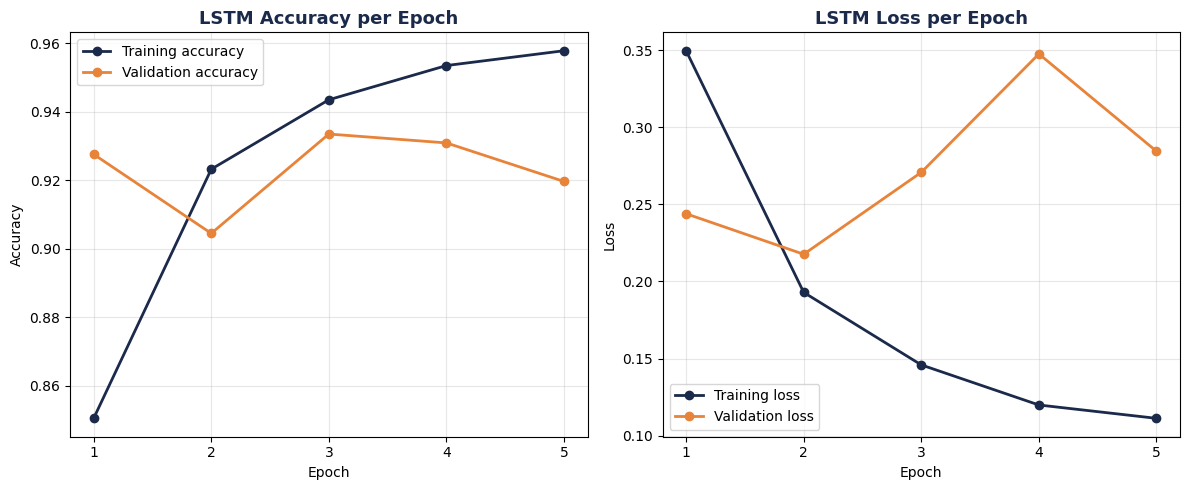

Figure saved to: /content/drive/MyDrive/MSc-Project/outputs/fig_lstm_training_history.png


In [8]:
# Step 6c: Visualisation of LSTM training history
# Training and validation accuracy and loss are plotted across epochs
# to assess whether the model learned genuine patterns or overfit
# to the training data.

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Panel one: accuracy across epochs
axes[0].plot(history.history['accuracy'], label='Training accuracy',
             color='#1B2A4A', linewidth=2, marker='o')
axes[0].plot(history.history['val_accuracy'], label='Validation accuracy',
             color='#E8833A', linewidth=2, marker='o')
axes[0].set_title('LSTM Accuracy per Epoch', fontsize=13,
                  fontweight='bold', color='#1B2A4A')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Accuracy')
axes[0].legend()
axes[0].grid(alpha=0.3)
axes[0].set_xticks(range(EPOCHS))
axes[0].set_xticklabels(range(1, EPOCHS + 1))

# Panel two: loss across epochs
axes[1].plot(history.history['loss'], label='Training loss',
             color='#1B2A4A', linewidth=2, marker='o')
axes[1].plot(history.history['val_loss'], label='Validation loss',
             color='#E8833A', linewidth=2, marker='o')
axes[1].set_title('LSTM Loss per Epoch', fontsize=13,
                  fontweight='bold', color='#1B2A4A')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].legend()
axes[1].grid(alpha=0.3)
axes[1].set_xticks(range(EPOCHS))
axes[1].set_xticklabels(range(1, EPOCHS + 1))

plt.tight_layout()

lstm_history_path = f'{output_dir}/fig_lstm_training_history.png'
plt.savefig(lstm_history_path, dpi=300, bbox_inches='tight')
plt.show()
print("Figure saved to:", lstm_history_path)

## Stage 7: Model Comparison and Results

In [13]:
# Step 7: Model comparison — summary table and visualisation
# The performance metrics of all four models are compiled into a summary
# table for direct comparison. ROC-AUC is included as a threshold-independent
# measure of discriminative ability. This output constitutes the primary
# answer to RQ2.

from sklearn.metrics import roc_auc_score

# ROC-AUC scores are computed using predicted probabilities
# Each model returns the probability of the positive class (sentiment = 1)
lr_prob   = lr_model.predict_proba(X_test)[:, 1]
rf_prob   = rf_model.predict_proba(X_test)[:, 1]
xgb_prob  = xgb_model.predict_proba(X_test)[:, 1]
lstm_prob = y_pred_lstm_prob.flatten()   # already computed in Step 6b

lr_roc   = roc_auc_score(y_test,      lr_prob)
rf_roc   = roc_auc_score(y_test,      rf_prob)
xgb_roc  = roc_auc_score(y_test,      xgb_prob)
lstm_roc = roc_auc_score(y_test_lstm, lstm_prob)

# Summary table is compiled
results = {
    'Model': ['Logistic Regression', 'Random Forest', 'XGBoost', 'LSTM'],
    'Accuracy (%)': [
        round(lr_accuracy  * 100, 2),
        round(rf_accuracy  * 100, 2),
        round(xgb_accuracy * 100, 2),
        round(lstm_accuracy* 100, 2)
    ],
    'Weighted F1': [
        round(lr_f1,   4),
        round(rf_f1,   4),
        round(xgb_f1,  4),
        round(lstm_f1, 4)
    ],
    'ROC-AUC': [
        round(lr_roc,   4),
        round(rf_roc,   4),
        round(xgb_roc,  4),
        round(lstm_roc, 4)
    ],
    'Negative Recall': [
        round(classification_report(y_test,      y_pred_lr,   output_dict=True)['0']['recall'], 4),
        round(classification_report(y_test,      y_pred_rf,   output_dict=True)['0']['recall'], 4),
        round(classification_report(y_test,      y_pred_xgb,  output_dict=True)['0']['recall'], 4),
        round(classification_report(y_test_lstm, y_pred_lstm, output_dict=True)['0']['recall'], 4)
    ],
    'Negative Precision': [
        round(classification_report(y_test,      y_pred_lr,   output_dict=True)['0']['precision'], 4),
        round(classification_report(y_test,      y_pred_rf,   output_dict=True)['0']['precision'], 4),
        round(classification_report(y_test,      y_pred_xgb,  output_dict=True)['0']['precision'], 4),
        round(classification_report(y_test_lstm, y_pred_lstm, output_dict=True)['0']['precision'], 4)
    ],
    'Training Time (s)': [
        round(lr_time,   1),
        round(rf_time,   1),
        round(xgb_time,  1),
        round(lstm_time, 1)
    ]
}

results_df = pd.DataFrame(results)
print("Model comparison summary:")
print(results_df.to_string(index=False))

# Summary table is saved to CSV
results_df.to_csv(f'{output_dir}/ml_model_comparison.csv', index=False)
print()
print("Summary table saved to outputs directory.")

Model comparison summary:
              Model  Accuracy (%)  Weighted F1  ROC-AUC  Negative Recall  Negative Precision  Training Time (s)
Logistic Regression         93.52       0.9379   0.9784           0.9252              0.7478                2.6
      Random Forest         92.44       0.9185   0.9633           0.6160              0.9016              202.3
            XGBoost         89.66       0.8786   0.9596           0.4040              0.9498              295.1
               LSTM         92.00       0.9232   0.9655           0.8759              0.7126               94.2

Summary table saved to outputs directory.


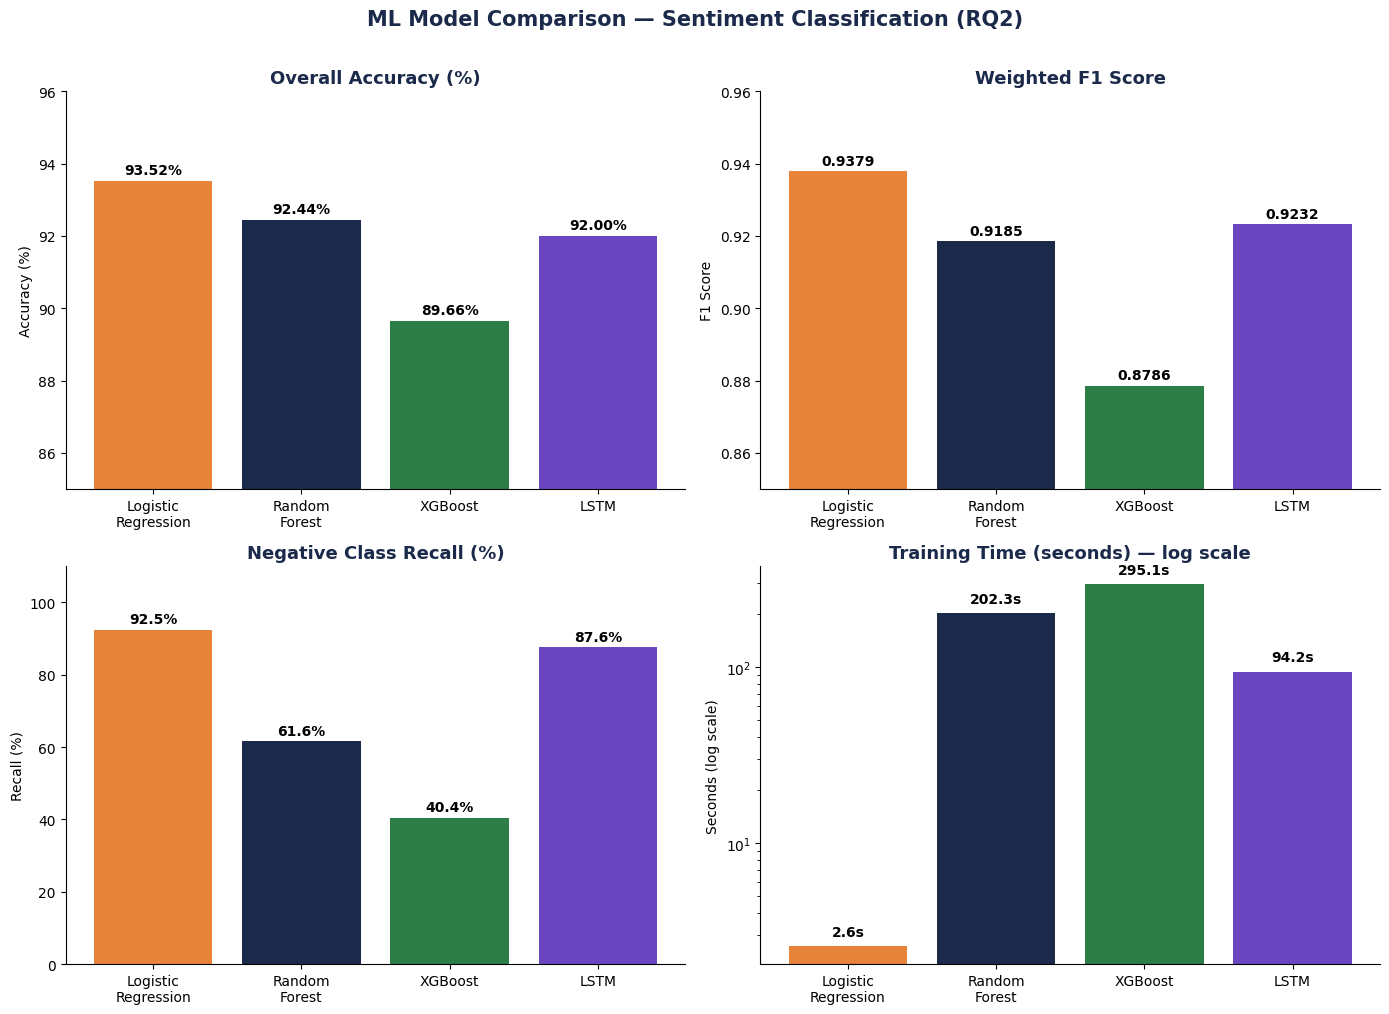

Figure saved to: /content/drive/MyDrive/MSc-Project/outputs/fig_ml_model_comparison.png


In [10]:
# Step 7b: Visualisation of model comparison results
# Four panels are produced comparing accuracy, weighted F1 score,
# negative class recall and training time across all four models.
# The figure constitutes the primary visual evidence for RQ2.

models = ['Logistic\nRegression', 'Random\nForest', 'XGBoost', 'LSTM']
colors = ['#E8833A', '#1B2A4A', '#2D7D46', '#6B46C1']

accuracies      = results_df['Accuracy (%)'].tolist()
f1_scores       = results_df['Weighted F1'].tolist()
neg_recalls     = [r * 100 for r in results_df['Negative Recall'].tolist()]
training_times  = results_df['Training Time (s)'].tolist()

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Panel 1: Accuracy
bars = axes[0, 0].bar(models, accuracies, color=colors)
axes[0, 0].set_title('Overall Accuracy (%)', fontsize=13,
                      fontweight='bold', color='#1B2A4A')
axes[0, 0].set_ylim(85, 96)
axes[0, 0].set_ylabel('Accuracy (%)')
for bar, val in zip(bars, accuracies):
    axes[0, 0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.1,
                    f'{val:.2f}%', ha='center', va='bottom',
                    fontsize=10, fontweight='bold')
axes[0, 0].spines['top'].set_visible(False)
axes[0, 0].spines['right'].set_visible(False)

# Panel 2: Weighted F1
bars = axes[0, 1].bar(models, f1_scores, color=colors)
axes[0, 1].set_title('Weighted F1 Score', fontsize=13,
                      fontweight='bold', color='#1B2A4A')
axes[0, 1].set_ylim(0.85, 0.96)
axes[0, 1].set_ylabel('F1 Score')
for bar, val in zip(bars, f1_scores):
    axes[0, 1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.001,
                    f'{val:.4f}', ha='center', va='bottom',
                    fontsize=10, fontweight='bold')
axes[0, 1].spines['top'].set_visible(False)
axes[0, 1].spines['right'].set_visible(False)

# Panel 3: Negative Recall
bars = axes[1, 0].bar(models, neg_recalls, color=colors)
axes[1, 0].set_title('Negative Class Recall (%)', fontsize=13,
                      fontweight='bold', color='#1B2A4A')
axes[1, 0].set_ylim(0, 110)
axes[1, 0].set_ylabel('Recall (%)')
for bar, val in zip(bars, neg_recalls):
    axes[1, 0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
                    f'{val:.1f}%', ha='center', va='bottom',
                    fontsize=10, fontweight='bold')
axes[1, 0].spines['top'].set_visible(False)
axes[1, 0].spines['right'].set_visible(False)

# Panel 4: Training time (log scale)
bars = axes[1, 1].bar(models, training_times, color=colors)
axes[1, 1].set_title('Training Time (seconds) — log scale', fontsize=13,
                      fontweight='bold', color='#1B2A4A')
axes[1, 1].set_yscale('log')
axes[1, 1].set_ylabel('Seconds (log scale)')
for bar, val in zip(bars, training_times):
    axes[1, 1].text(bar.get_x() + bar.get_width()/2, bar.get_height() * 1.1,
                    f'{val:.1f}s', ha='center', va='bottom',
                    fontsize=10, fontweight='bold')
axes[1, 1].spines['top'].set_visible(False)
axes[1, 1].spines['right'].set_visible(False)

plt.suptitle('ML Model Comparison — Sentiment Classification (RQ2)',
             fontsize=15, fontweight='bold', color='#1B2A4A', y=1.01)
plt.tight_layout()

comparison_fig_path = f'{output_dir}/fig_ml_model_comparison.png'
plt.savefig(comparison_fig_path, dpi=300, bbox_inches='tight')
plt.show()
print("Figure saved to:", comparison_fig_path)

## ROC-AUC Curves — Model Comparison

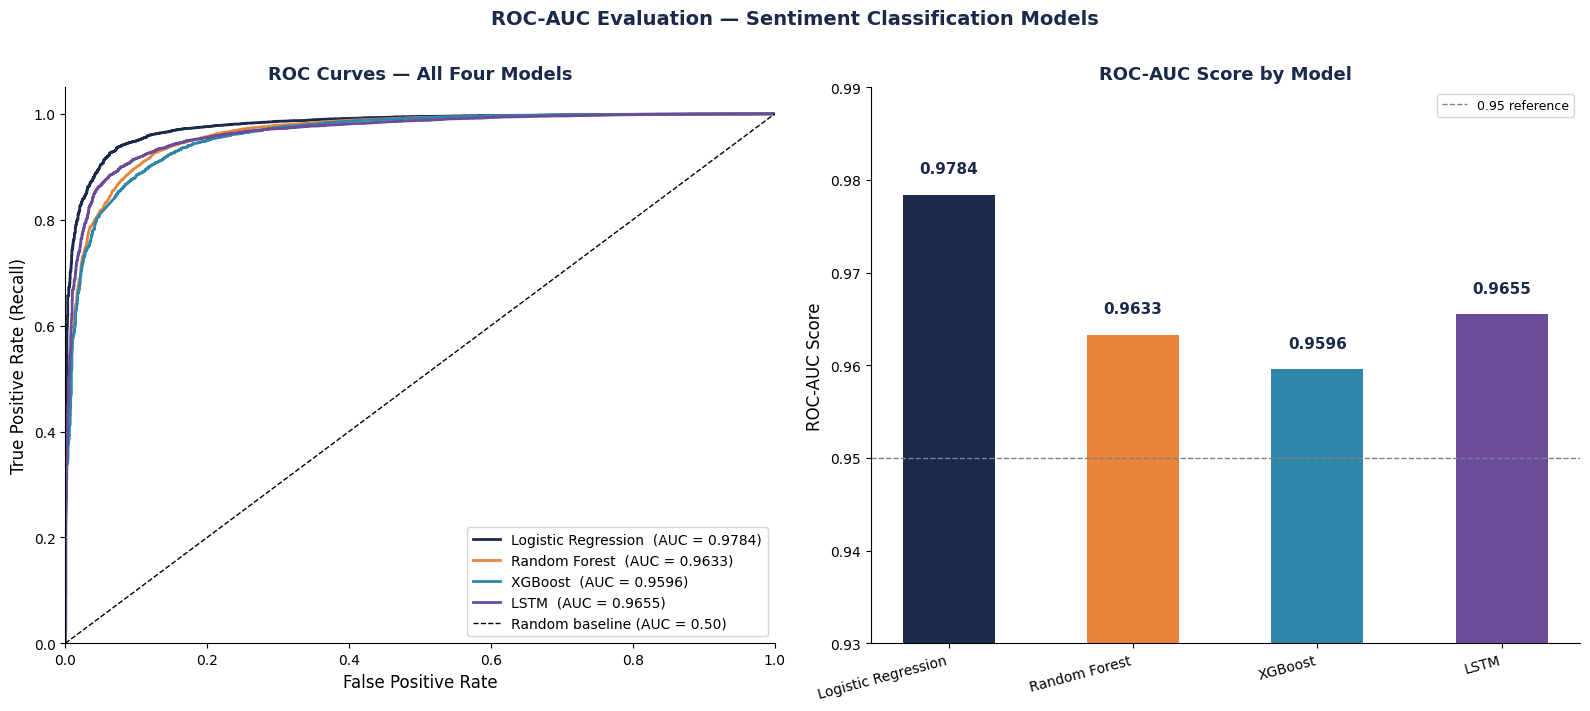

Figure saved to: /content/drive/MyDrive/MSc-Project/outputs/fig_roc_auc_comparison.png


In [14]:
# Step 7c: ROC-AUC curve visualisation for all four models
# ROC curves are plotted for each model on a single figure to provide
# a threshold-independent comparison of discriminative ability.
# A bar chart of AUC scores is included as a secondary panel for
# direct ranking. Both panels are saved at 300 dpi.

from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt
import numpy as np

# Predicted probabilities for each model (already computed in Step 7)
models_prob = {
    'Logistic Regression' : (y_test,      lr_prob,   0.9784, '#1B2A4A'),
    'Random Forest'        : (y_test,      rf_prob,   0.9633, '#E8833A'),
    'XGBoost'              : (y_test,      xgb_prob,  0.9596, '#2E86AB'),
    'LSTM'                 : (y_test_lstm, lstm_prob, 0.9655, '#6B4C9A')
}

fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# ── Panel 1: ROC curves ──────────────────────────────────────────────
ax = axes[0]

for model_name, (y_true, y_prob, auc_score, colour) in models_prob.items():
    fpr, tpr, _ = roc_curve(y_true, y_prob)
    ax.plot(fpr, tpr, label=f'{model_name}  (AUC = {auc_score:.4f})',
            color=colour, linewidth=2)

# Random baseline
ax.plot([0, 1], [0, 1], 'k--', linewidth=1, label='Random baseline (AUC = 0.50)')

ax.set_xlabel('False Positive Rate', fontsize=12)
ax.set_ylabel('True Positive Rate (Recall)', fontsize=12)
ax.set_title('ROC Curves — All Four Models', fontsize=13,
             fontweight='bold', color='#1B2A4A')
ax.legend(loc='lower right', fontsize=10)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.set_xlim([0.0, 1.0])
ax.set_ylim([0.0, 1.05])

# ── Panel 2: AUC bar chart ───────────────────────────────────────────
ax2 = axes[1]

model_names = list(models_prob.keys())
auc_scores  = [v[2] for v in models_prob.values()]
colours     = [v[3] for v in models_prob.values()]

bars = ax2.bar(model_names, auc_scores, color=colours, width=0.5)

# Value labels on bars
for bar, score in zip(bars, auc_scores):
    ax2.text(bar.get_x() + bar.get_width() / 2,
             bar.get_height() + 0.002,
             f'{score:.4f}',
             ha='center', va='bottom',
             fontsize=11, fontweight='bold', color='#1B2A4A')

ax2.set_ylim([0.93, 0.99])
ax2.set_ylabel('ROC-AUC Score', fontsize=12)
ax2.set_title('ROC-AUC Score by Model', fontsize=13,
              fontweight='bold', color='#1B2A4A')
ax2.set_xticklabels(model_names, rotation=15, ha='right', fontsize=10)
ax2.spines['top'].set_visible(False)
ax2.spines['right'].set_visible(False)

# Reference line at 0.95
ax2.axhline(y=0.95, color='grey', linestyle='--',
            linewidth=1, label='0.95 reference')
ax2.legend(fontsize=9)

plt.suptitle('ROC-AUC Evaluation — Sentiment Classification Models',
             fontsize=14, fontweight='bold', color='#1B2A4A', y=1.01)
plt.tight_layout()

fig_path = f'{output_dir}/fig_roc_auc_comparison.png'
plt.savefig(fig_path, dpi=300, bbox_inches='tight')
plt.show()
print("Figure saved to:", fig_path)

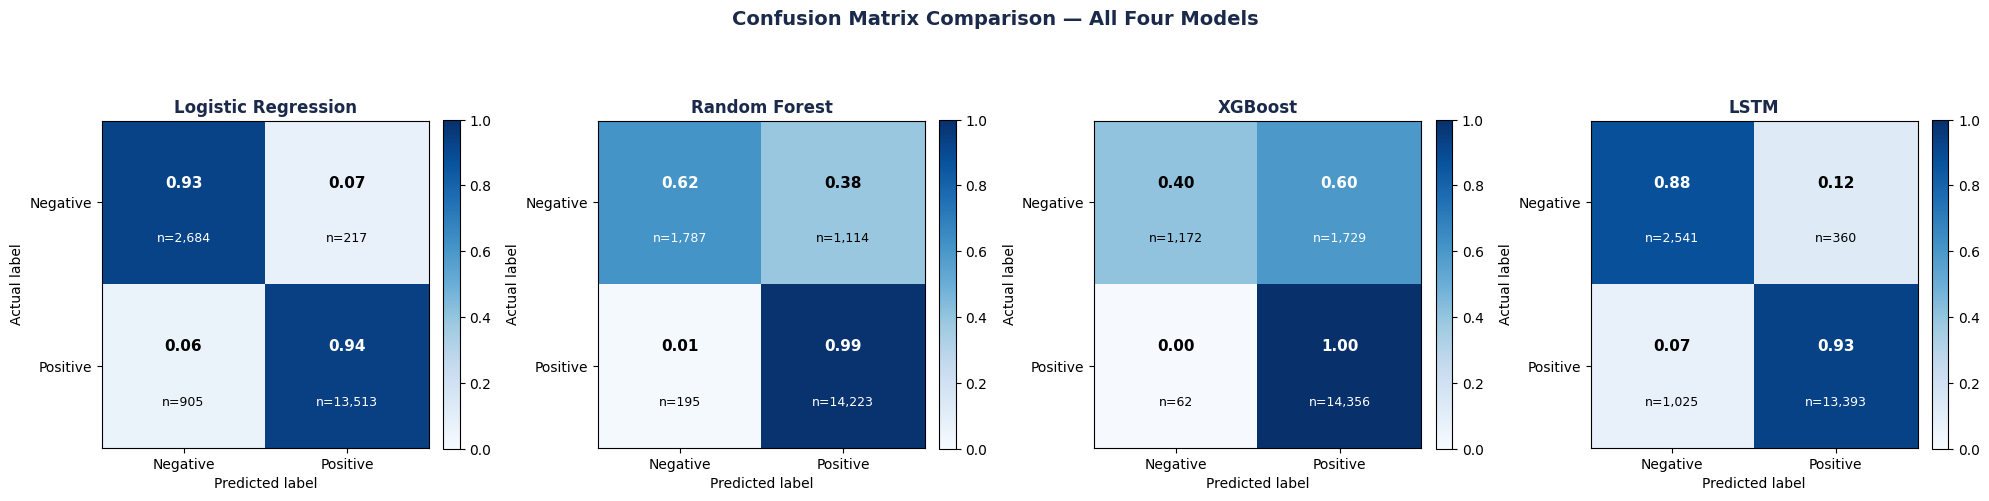

Figure saved to: /content/drive/MyDrive/MSc-Project/outputs/fig_confusion_matrix_comparison.png


In [11]:
# Step 8: Confusion matrix comparison across all four models
# Normalised confusion matrices are produced for each model to allow
# direct visual comparison of classification patterns. Normalisation
# by row converts raw counts to proportions so that matrices remain
# comparable despite different test set sizes.

import matplotlib.pyplot as plt
import numpy as np

fig, axes = plt.subplots(1, 4, figsize=(20, 5))

model_names = ['Logistic Regression', 'Random Forest', 'XGBoost', 'LSTM']
conf_matrices = [lr_cm, rf_cm, xgb_cm, lstm_cm]
colors_list = ['Blues', 'Blues', 'Blues', 'Blues']
class_labels = ['Negative', 'Positive']

for i, (ax, cm, name) in enumerate(zip(axes, conf_matrices, model_names)):
    # Each row is normalised to proportions
    cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)

    image = ax.imshow(cm_norm, cmap='Blues', vmin=0, vmax=1)

    ax.set_xticks(range(2))
    ax.set_yticks(range(2))
    ax.set_xticklabels(class_labels)
    ax.set_yticklabels(class_labels)
    ax.set_xlabel('Predicted label', fontsize=10)
    ax.set_ylabel('Actual label', fontsize=10)
    ax.set_title(name, fontsize=12, fontweight='bold', color='#1B2A4A')

    # Each cell is annotated with proportion and raw count
    for row in range(2):
        for col in range(2):
            proportion = cm_norm[row, col]
            raw = cm[row, col]
            text_color = 'white' if proportion > 0.5 else 'black'
            ax.text(col, row - 0.12, f'{proportion:.2f}',
                    ha='center', va='center',
                    fontsize=11, fontweight='bold', color=text_color)
            ax.text(col, row + 0.22, f'n={raw:,}',
                    ha='center', va='center',
                    fontsize=9, color=text_color)

    plt.colorbar(image, ax=ax, fraction=0.046, pad=0.04)

plt.suptitle('Confusion Matrix Comparison — All Four Models',
             fontsize=14, fontweight='bold', color='#1B2A4A', y=1.02)
plt.tight_layout()

cm_fig_path = f'{output_dir}/fig_confusion_matrix_comparison.png'
plt.savefig(cm_fig_path, dpi=300, bbox_inches='tight')
plt.show()
print("Figure saved to:", cm_fig_path)

##Stage 8: Outputs and Model Selection

In [12]:
# Step 9: Saving the selected model and final outputs
# Logistic Regression is selected as the best performing model based on
# accuracy, weighted F1 score, negative class recall and training
# efficiency. The model, vectoriser and predictions are saved for
# use in the composite scoring stage (Notebook 05).

import joblib

# The selected model and TF-IDF vectoriser are saved to Google Drive
model_dir = '/content/drive/MyDrive/MSc-Project/models'
os.makedirs(model_dir, exist_ok=True)

joblib.dump(lr_model, f'{model_dir}/lr_sentiment_model.pkl')
joblib.dump(tfidf, f'{model_dir}/tfidf_vectoriser.pkl')

print("Model saved:", f'{model_dir}/lr_sentiment_model.pkl')
print("Vectoriser saved:", f'{model_dir}/tfidf_vectoriser.pkl')

# ML predictions are added to the binary corpus and saved
df_binary['ml_sentiment'] = lr_model.predict(
    tfidf.transform(df_binary['clean_text'].fillna('')))
df_binary['ml_sentiment_label'] = df_binary['ml_sentiment'].map(
    {1: 'positive', 0: 'negative'})

ml_output_path = '/content/drive/MyDrive/MSc-Project/data/reviews_ml_scored.csv'
df_binary.to_csv(ml_output_path, index=False)
print("ML scored corpus saved:", ml_output_path)

# A final summary of all outputs is printed
print()
print("=" * 55)
print("Notebook 04 — Final Output Summary")
print("=" * 55)
print()
print("Selected model  : Logistic Regression")
print(f"Accuracy        : {lr_accuracy*100:.2f}%")
print(f"Weighted F1     : {lr_f1:.4f}")
print(f"Negative recall : {results_df.loc[0, 'Negative Recall']*100:.2f}%")
print(f"Training time   : {lr_time:.1f} seconds")
print()
print("Files saved to Google Drive:")
print("  models/lr_sentiment_model.pkl")
print("  models/tfidf_vectoriser.pkl")
print("  data/reviews_ml_scored.csv")
print("  outputs/ml_model_comparison.csv")
print("  outputs/fig_ml_model_comparison.png")
print("  outputs/fig_confusion_matrix_comparison.png")
print("  outputs/fig_lstm_training_history.png")

Model saved: /content/drive/MyDrive/MSc-Project/models/lr_sentiment_model.pkl
Vectoriser saved: /content/drive/MyDrive/MSc-Project/models/tfidf_vectoriser.pkl
ML scored corpus saved: /content/drive/MyDrive/MSc-Project/data/reviews_ml_scored.csv

Notebook 04 — Final Output Summary

Selected model  : Logistic Regression
Accuracy        : 93.52%
Weighted F1     : 0.9379
Negative recall : 92.52%
Training time   : 2.6 seconds

Files saved to Google Drive:
  models/lr_sentiment_model.pkl
  models/tfidf_vectoriser.pkl
  data/reviews_ml_scored.csv
  outputs/ml_model_comparison.csv
  outputs/fig_ml_model_comparison.png
  outputs/fig_confusion_matrix_comparison.png
  outputs/fig_lstm_training_history.png
